# Heart Disease Prediction

In [4]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Upload and load the dataset

uploaded = files.upload()

df = pd.read_csv("heart.csv")

df.head()

Saving heart.csv to heart (1).csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
# Explore the dataset

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

print("\nDataset Information:")
df.info()

Dataset Shape: (302, 14)

First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows: 0

Target Distribution:
target
1    164
0    138
Name: count, dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64 

In [5]:
# Prepare the dataset for model training

# Remove duplicate records
df = df.drop_duplicates()

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nPreprocessing Summary")
print("- Duplicate rows removed.")
print("- No missing values found.")
print("- No categorical columns to encode.")
print("- Dataset split into 80% training and 20% testing.")

Training Data: (241, 13)
Testing Data: (61, 13)

Preprocessing Summary
- Duplicate rows removed.
- No missing values found.
- No categorical columns to encode.
- Dataset split into 80% training and 20% testing.


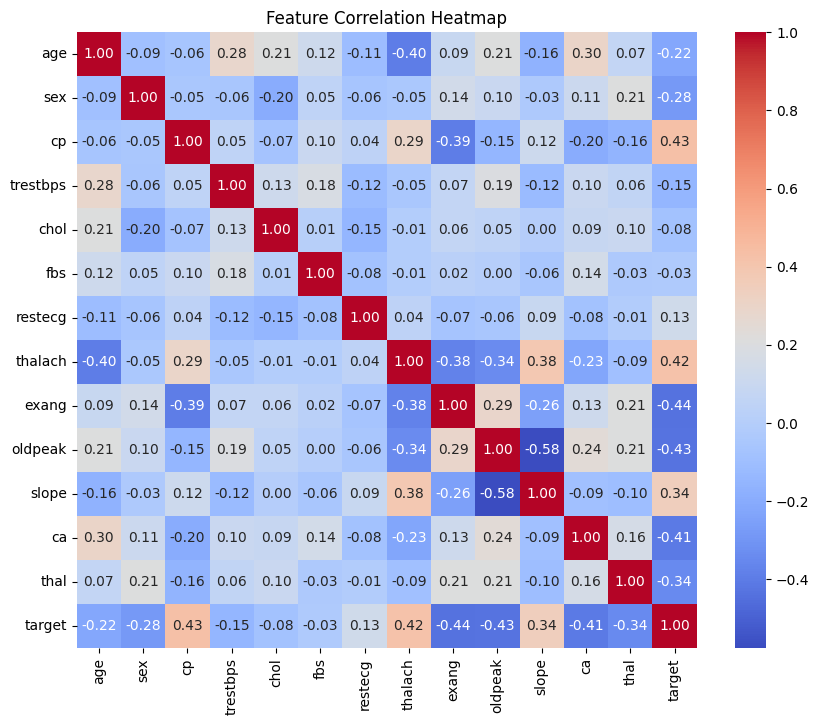

Feature Engineering Summary
- Correlation analysis was used to study feature relationships.
- No feature was removed because all features contribute useful information.


In [7]:
# Check how the features are related

plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

print("Feature Engineering Summary")
print("- Correlation analysis was used to study feature relationships.")
print("- No feature was removed because all features contribute useful information.")

In [8]:
# Train the Logistic Regression model

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
# Train the Random Forest model

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [10]:
# Train the KNN model

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN model trained successfully.")

KNN model trained successfully.


In [11]:
# Compare the performance of all models

models = {
    "Logistic Regression": log_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred
}

results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall": round(recall_score(y_test, pred), 4),
        "F1 Score": round(f1_score(y_test, pred), 4)
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7869,0.7222,0.8966,0.8000
1,Random Forest,0.8361,0.7879,0.8966,0.8387
2,KNN,0.6393,0.5814,0.8621,0.6944


Best Model: Random Forest


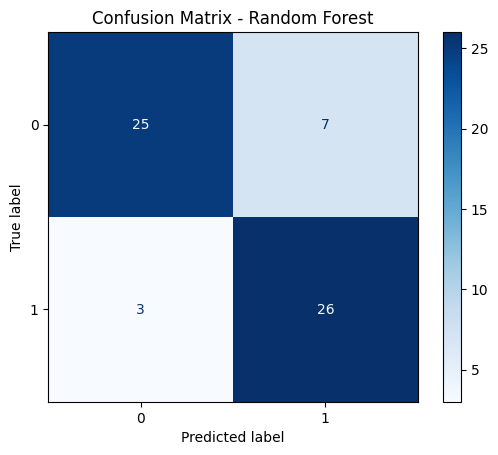

In [12]:
# Display the confusion matrix for the best model

best_model = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model)

if best_model == "Logistic Regression":
    best_pred = log_pred
elif best_model == "Random Forest":
    best_pred = rf_pred
else:
    best_pred = knn_pred

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model}")

plt.show()

## Conclusion

1. Three machine learning models were trained to predict the presence of heart disease using the given dataset.

2. All models were evaluated using Accuracy, Precision, Recall, and F1 Score to compare their performance.

3. **Random Forest** achieved the best overall performance on the test dataset, making it the most suitable model for this problem.

4. The confusion matrix showed that the model correctly classified most of the patients with very few misclassifications.

5. This project demonstrates how machine learning can be used to analyze medical data and assist in heart disease prediction.